In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import math
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             precision_recall_curve, classification_report)

In [ ]:
TRAIN_PATH = "/media/lazy/28481E65481E31D4/Placement Drive/AI ML Position/Dataset/train_preprocessed.csv"
TEST_PATH = "/media/lazy/28481E65481E31D4/Placement Drive/AI ML Position/Dataset/test_preprocessed.csv"

MODEL_FILES = {
    "best_lr": "best_logistic_regression.joblib",
    "best_rf_tuned": "best_random_forest.joblib",
    "rf_old": "random_forest_best.joblib"
}

OUT_DIR = "."
PLOT_DPI = 150

In [ ]:
def extract_title(name):
    try:
        return name.split(',')[1].split('.')[0].strip()
    except Exception:
        return "Unknown"


def engineer_features_for_test(train_df, test_df):
    tr = train_df.copy()
    te = test_df.copy()
    # Title
    if 'Name' in tr.columns:
        tr['Title'] = tr['Name'].astype(str).apply(extract_title)
        te['Title'] = te['Name'].astype(str).apply(extract_title)
        
        common_titles = tr['Title'].value_counts(
        ).loc[lambda s: s >= 10].index.tolist()
        tr['Title'] = tr['Title'].where(
            tr['Title'].isin(common_titles), 'Rare')
        te['Title'] = te['Title'].where(
            te['Title'].isin(common_titles), 'Rare')
    # Age missing indicator
    tr['Age_missing'] = tr['Age'].isna().astype(int)
    te['Age_missing'] = te['Age'].isna().astype(int)
    # Age_band
    age_bins = [0, 1, 12, 18, 30, 50, 65, 120]
    age_labels = ['Infant', 'Child', 'Teen',
                  'YoungAdult', 'Adult', 'Middle', 'Senior']
    age_med = tr['Age'].median()
    tr['Age_band'] = pd.cut(tr['Age'].fillna(
        age_med), bins=age_bins, labels=age_labels)
    te['Age_band'] = pd.cut(te['Age'].fillna(
        age_med), bins=age_bins, labels=age_labels)
    # Fare log & bins
    fare_med = tr['Fare'].median()
    tr['Fare_log'] = np.log1p(tr['Fare'].fillna(fare_med))
    te['Fare_log'] = np.log1p(te['Fare'].fillna(fare_med))
    try:
        tr['Fare_bin'] = pd.qcut(tr['Fare'].fillna(
            fare_med), q=4, labels=False, duplicates='drop')
        edges = tr['Fare'].fillna(fare_med).quantile(
            [0, 0.25, 0.5, 0.75, 1.0]).values
        te['Fare_bin'] = pd.cut(te['Fare'].fillna(fare_med), bins=np.unique(
            edges), labels=False, include_lowest=True)
    except Exception:
        tr['Fare_bin'] = pd.cut(tr['Fare'].fillna(
            fare_med), bins=4, labels=False)
        te['Fare_bin'] = pd.cut(te['Fare'].fillna(
            fare_med), bins=4, labels=False)
    return tr, te

In [4]:
if not os.path.exists(TRAIN_PATH) or not os.path.exists(TEST_PATH):
    raise FileNotFoundError(
        "Make sure train_preprocessed.csv and test_preprocessed.csv exist in this working directory.")

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
print("Loaded: train", train_df.shape, " test", test_df.shape)

Loaded: train (891, 22)  test (418, 20)


In [5]:
train_fe, test_fe = engineer_features_for_test(train_df, test_df)

In [8]:
FEATURES = [c for c in train_fe.columns if c not in ('Survived', 'Name')]
X_train_ref = train_fe[FEATURES].copy()
X_test_proc = test_fe.reindex(columns=FEATURES, fill_value=0).copy()

print("Missing columns were filled with zero where necessary.")
print("Columns aligned:", list(X_train_ref.columns) == list(X_test_proc.columns))

Missing columns were filled with zero where necessary.
Columns aligned: True


In [9]:
for df in (X_train_ref, X_test_proc):
    for c in df.select_dtypes(include=['bool']).columns:
        df[c] = df[c].astype(int)

In [10]:
num_cols = X_train_ref.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_ref.select_dtypes(
    include=['object', 'category']).columns.tolist()

print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)

Numeric cols: ['PassengerId', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin_Known', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_U', 'FamilySize', 'IsAlone', 'Age_missing', 'Fare_log', 'Fare_bin']
Categorical cols: ['Embarked', 'Title', 'Age_band']


In [11]:
num_imp = SimpleImputer(strategy='median')
if num_cols:
    X_train_ref[num_cols] = num_imp.fit_transform(X_train_ref[num_cols])
    X_test_proc[num_cols] = num_imp.transform(X_test_proc[num_cols])

In [12]:
for c in cat_cols:
    fill = X_train_ref[c].mode(dropna=True)
    fill_val = fill.iloc[0] if not fill.empty else "Missing"
    X_train_ref[c] = X_train_ref[c].fillna(fill_val)
    if c in X_test_proc.columns:
        X_test_proc[c] = X_test_proc[c].fillna(fill_val)

if cat_cols:
    combined = pd.concat(
        [X_train_ref[cat_cols], X_test_proc[cat_cols]], axis=0, ignore_index=True)
    dummies = pd.get_dummies(combined, columns=cat_cols,
                             prefix=cat_cols, drop_first=False)
    X_train_ohe = dummies.iloc[:len(X_train_ref)].set_index(X_train_ref.index)
    X_test_ohe = dummies.iloc[len(X_train_ref):].set_index(X_test_proc.index)
    X_train_final = pd.concat(
        [X_train_ref.drop(columns=cat_cols), X_train_ohe], axis=1)
    X_test_final = pd.concat(
        [X_test_proc.drop(columns=cat_cols), X_test_ohe], axis=1)
else:
    X_train_final = X_train_ref.copy()
    X_test_final = X_test_proc.copy()

In [ ]:
X_train_final, X_test_final = X_train_final.align(
    X_test_final, join='left', axis=1, fill_value=0)
print("Final feature shapes -> train:",
      X_train_final.shape, " test:", X_test_final.shape)

loaded_models = {}
for key, fname in MODEL_FILES.items():
    if os.path.exists(fname):
        try:
            loaded_models[key] = joblib.load(fname)
            print(f"Loaded model: {key} from {fname}")
        except Exception as e:
            print(f"Failed to load {fname}: {e}")
    else:
        print(f"Model file not found: {fname} (skipping)")

if not loaded_models:
    raise RuntimeError(
        "No model files found. Put model .joblib files in working directory and re-run.")

Final feature shapes -> train: (891, 37)  test: (418, 37)
Loaded model: best_lr from best_logistic_regression.joblib
Loaded model: best_rf_tuned from best_random_forest.joblib
Loaded model: rf_old from random_forest_best.joblib


In [ ]:
predictions = {}
probas = {}

def _model_expected_features(model):
    if hasattr(model, "feature_names_in_"):
        return list(model.feature_names_in_)
   
    if hasattr(model, "named_steps"):
        for step in model.named_steps.values():
            if hasattr(step, "feature_names_in_"):
                return list(step.feature_names_in_)
  
    if hasattr(model, "estimator_") and hasattr(model.estimator_, "feature_names_in_"):
        return list(model.estimator_.feature_names_in_)
    return None

train_cols_available = 'X_train_final' in globals()

for name, model in loaded_models.items():
    print(f"\n--- Predicting with model: {name} ---")
    expected = _model_expected_features(model)

    if expected is not None:
        X_model = X_test_final.reindex(columns=expected, fill_value=0).copy()
        print(
            f"Model '{name}': using model.feature_names_in_ with {len(expected)} features.")
    else:
        if train_cols_available:
            expected = list(X_train_final.columns)
            X_model = X_test_final.reindex(
                columns=expected, fill_value=0).copy()
            print(
                f"Model '{name}': model did not expose feature names; used X_train_final.columns ({len(expected)} features).")
        else:
            if hasattr(model, "n_features_in_"):
                n_expected = model.n_features_in_
                if X_test_final.shape[1] == n_expected:
                    X_model = X_test_final.copy()
                    print(
                        f"Model '{name}': no names but column count matches ({n_expected}). Using X_test_final as-is.")
                else:
                    raise ValueError(
                        f"Model '{name}' expects {n_expected} features but X_test_final has {X_test_final.shape[1]}. "
                        "Provide X_train_final (training feature names) or ensure preprocessing alignment."
                    )
            else:
                raise RuntimeError(
                    f"Model '{name}' does not expose expected feature names or n_features_in_. Cannot safely prepare X for prediction.")

    
    for c in X_model.select_dtypes(include=['bool']).columns:
        X_model[c] = X_model[c].astype(int)
    X_model = X_model.fillna(0)

    try:
        y_pred = model.predict(X_model)
    except Exception as e:
        try:
            y_pred = model.predict(X_model.values)
            print(
                f"Warning: model.predict required ndarray fallback for model '{name}'.")
        except Exception as e2:
            raise RuntimeError(f"Prediction failed for model '{name}': {e2}")

    y_proba = None
    try:
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_model)[:, 1]
        elif hasattr(model, "decision_function"):
            df_vals = model.decision_function(X_model)
            if df_vals.ndim == 1:
                y_proba = 1.0 / (1.0 + np.exp(-df_vals))  # sigmoid
            else:
                y_proba = None
    except Exception:
        try:
            if hasattr(model, "predict_proba"):
                y_proba = model.predict_proba(X_model.values)[:, 1]
            elif hasattr(model, "decision_function"):
                df_vals = model.decision_function(X_model.values)
                if df_vals.ndim == 1:
                    y_proba = 1.0 / (1.0 + np.exp(-df_vals))
        except Exception:
            y_proba = None

    predictions[name] = np.asarray(y_pred)
    probas[name] = (np.asarray(y_proba) if y_proba is not None else None)

    # report
    vc = pd.Series(predictions[name]).value_counts().to_dict()
    print(f"Predicted distribution for '{name}': {vc}")
    if probas[name] is not None:
        print(
            f"Probabilities available for '{name}' (sample):", probas[name][:5])

if 'orig_test' in globals() and 'PassengerId' in orig_test.columns:
    for name, preds in predictions.items():
        out = f"{name}_submission_aligned.csv"
        pd.DataFrame({'PassengerId': orig_test['PassengerId'], 'Survived': preds.astype(
            int)}).to_csv(out, index=False)
        print("Saved submission:", out)
else:
    print("orig_test not available or missing PassengerId; not saving submissions automatically.")


--- Predicting with model: best_lr ---
Model 'best_lr': using model.feature_names_in_ with 21 features.
Predicted distribution for 'best_lr': {0: 256, 1: 162}
Probabilities available for 'best_lr' (sample): [0.12712043 0.4159408  0.09955684 0.09502389 0.59443268]

--- Predicting with model: best_rf_tuned ---
Model 'best_rf_tuned': using model.feature_names_in_ with 21 features.
Predicted distribution for 'best_rf_tuned': {0: 277, 1: 141}
Probabilities available for 'best_rf_tuned' (sample): [0.12729397 0.35920838 0.0761257  0.19984529 0.3884545 ]

--- Predicting with model: rf_old ---
Model 'rf_old': using model.feature_names_in_ with 20 features.
Predicted distribution for 'rf_old': {0: 267, 1: 151}
Probabilities available for 'rf_old' (sample): [0.11188095 0.30061544 0.0460119  0.36984921 0.39828175]
orig_test not available or missing PassengerId; not saving submissions automatically.


In [20]:
orig_test = pd.read_csv(TEST_PATH)
if 'PassengerId' in orig_test.columns:
    for name, y_pred in predictions.items():
        outname = os.path.join(OUT_DIR, f"{name}_submission.csv")
        pd.DataFrame({'PassengerId': orig_test['PassengerId'], 'Survived': y_pred.astype(
            int)}).to_csv(outname, index=False)
        print("Saved submission:", outname)
else:
    print("PassengerId not in test file; not saving submission CSVs.")

Saved submission: ./best_lr_submission.csv
Saved submission: ./best_rf_tuned_submission.csv
Saved submission: ./rf_old_submission.csv


Has ground-truth labels in test: False
No ground-truth in test: skipping confusion matrices and metric bar chart.
Skipping ROC / PR plots because test is unlabeled.
No feature_importances_ found for model best_lr (skipping)


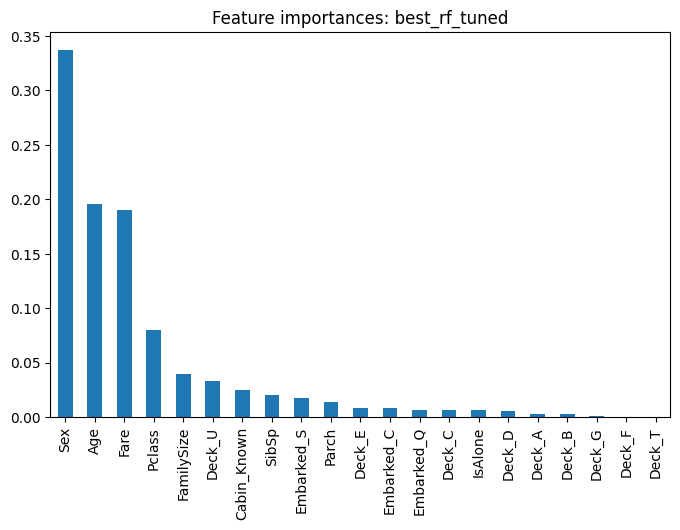

Saved: ./feature_importances_best_rf_tuned.png


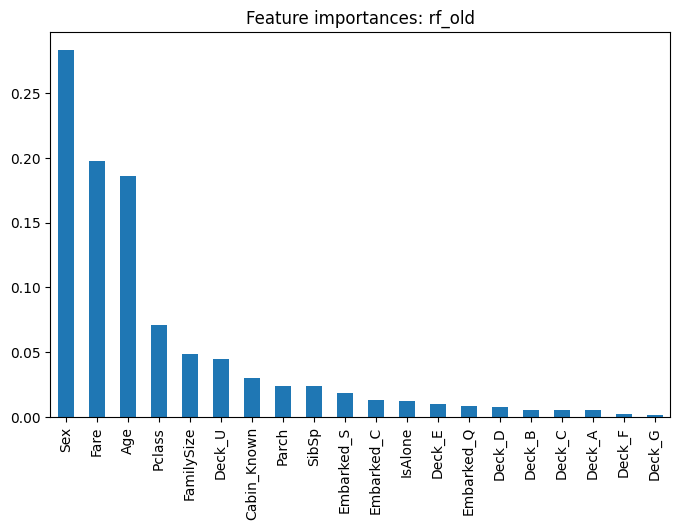

Saved: ./feature_importances_rf_old.png
Skipping metrics comparison (no ground-truth).


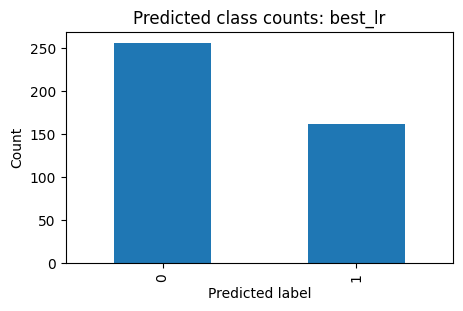

Saved: ./pred_counts_best_lr.png


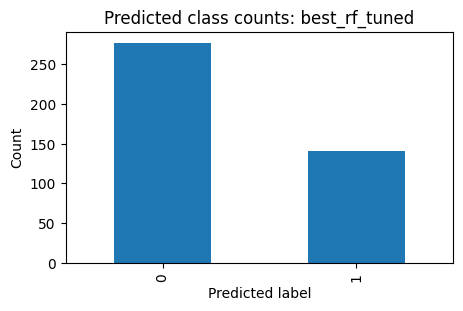

Saved: ./pred_counts_best_rf_tuned.png


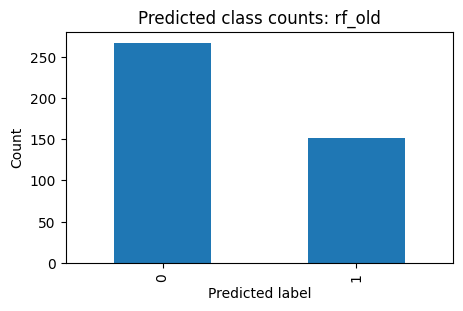

Saved: ./pred_counts_rf_old.png


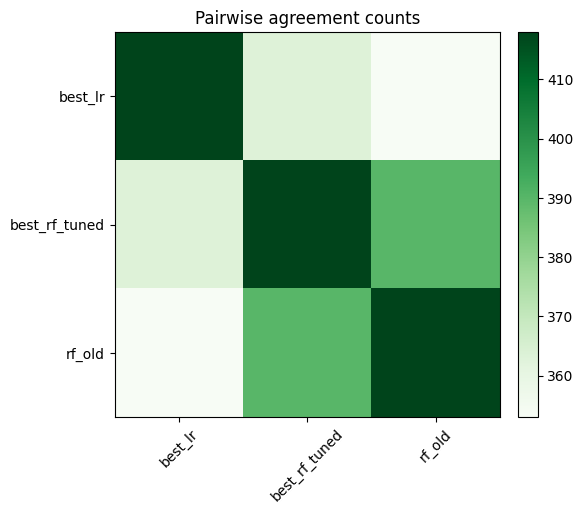

Saved: ./agreement_matrix.png
Plotting block finished. Check the working directory for PNG files.


In [ ]:
vars_needed = ['predictions', 'probas',
               'loaded_models', 'test_df', 'X_test_final']
missing_vars = [v for v in vars_needed if v not in globals()]
if missing_vars:
    print("Warning: some expected variables are missing:", missing_vars)

has_ground_truth = ('Survived' in globals().get(
    'test_df', pd.DataFrame()).columns)
print("Has ground-truth labels in test:", has_ground_truth)

preds = globals().get('predictions', {})
probs = globals().get('probas', {})

if not preds:
    raise RuntimeError(
        "No predictions found. Run the prediction loop first and ensure 'predictions' dict exists.")

def _save_show(fig, fname):
    fig.savefig(fname, dpi=PLOT_DPI, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print("Saved:", fname)


# 1) If ground truth present -> compute metrics and plot confusion matrix per model
metrics_summary = {}
if has_ground_truth:
    y_true = test_df['Survived'].values
    for name, y_pred in preds.items():
        m = {}
        m['accuracy'] = accuracy_score(y_true, y_pred)
        m['precision'] = precision_score(y_true, y_pred, zero_division=0)
        m['recall'] = recall_score(y_true, y_pred, zero_division=0)
        m['f1'] = f1_score(y_true, y_pred, zero_division=0)
        m['cm'] = confusion_matrix(y_true, y_pred)
        m['correct'] = int(m['cm'].trace())
        metrics_summary[name] = m

        # print metrics
        print(f"\nModel: {name}")
        print(
            f" Accuracy: {m['accuracy']:.4f}, Precision: {m['precision']:.4f}, Recall: {m['recall']:.4f}, F1: {m['f1']:.4f}")
        print(" Confusion matrix:\n", m['cm'])
        print("\nClassification report:\n", classification_report(
            y_true, y_pred, zero_division=0))

        # plot confusion matrix
        fig, ax = plt.subplots(figsize=(4.2, 4))
        cm = m['cm']
        im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
        ax.set_title(f"Confusion: {name}")
        plt.colorbar(im, fraction=0.046, pad=0.04)
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        thresh = cm.max() / 2.
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, format(int(cm[i, j]), 'd'),
                        ha="center", va="center",
                        color="white" if cm[i, j] > thresh else "black")
        fname = os.path.join(OUT_DIR, f"confusion_{name}.png")
        _save_show(fig, fname)
else:
    print("No ground-truth in test: skipping confusion matrices and metric bar chart.")

# 2) ROC and Precision-Recall curves (only if has_ground_truth and probabilities exist)
if has_ground_truth:
    # ROC
    any_roc = False
    fig, ax = plt.subplots(figsize=(7, 6))
    for name, p in probs.items():
        if p is None:
            continue
        try:
            fpr, tpr, _ = roc_curve(y_true, p)
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc:.3f})")
            any_roc = True
        except Exception as e:
            print(f"Skipped ROC for {name}: {e}")
    if any_roc:
        ax.plot([0, 1], [0, 1], 'k--', lw=1)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title("ROC curves")
        ax.legend(loc="lower right")
        fname = os.path.join(OUT_DIR, "roc_curves.png")
        _save_show(fig, fname)
    else:
        print("No valid probabilities for ROC plot.")

    # PR curve
    any_pr = False
    fig, ax = plt.subplots(figsize=(7, 6))
    for name, p in probs.items():
        if p is None:
            continue
        try:
            prec, rec, _ = precision_recall_curve(y_true, p)
            pr_auc = auc(rec, prec)
            ax.plot(rec, prec, lw=2, label=f"{name} (AUC={pr_auc:.3f})")
            any_pr = True
        except Exception as e:
            print(f"Skipped PR for {name}: {e}")
    if any_pr:
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_title("Precision-Recall curves")
        ax.legend(loc="best")
        fname = os.path.join(OUT_DIR, "pr_curves.png")
        _save_show(fig, fname)
    else:
        print("No valid probabilities for PR plot.")
else:
    print("Skipping ROC / PR plots because test is unlabeled.")

# 3) Feature importances for RF-like models (attempt to extract)
for name, model in loaded_models.items():
    imp = None
    try:
        if hasattr(model, "feature_importances_"):
            imp = model.feature_importances_
        elif hasattr(model, "named_steps"):
            # check pipeline steps
            for step in model.named_steps.values():
                if hasattr(step, "feature_importances_"):
                    imp = step.feature_importances_
                    break
        elif hasattr(model, "estimator_") and hasattr(model.estimator_, "feature_importances_"):
            imp = model.estimator_.feature_importances_
    except Exception:
        imp = None

    if imp is not None:
        # determine feature names used (try model.feature_names_in_, else X_test_final columns)
        if hasattr(model, "feature_names_in_"):
            feat_names = list(model.feature_names_in_)
        elif 'X_train_final' in globals():
            feat_names = list(X_train_final.columns)
        else:
            feat_names = list(X_test_final.columns)
        fi = pd.Series(imp, index=feat_names).sort_values(
            ascending=False).head(25)
        fig, ax = plt.subplots(figsize=(8, 5))
        fi.plot(kind='bar', ax=ax)
        ax.set_title(f"Feature importances: {name}")
        fname = os.path.join(OUT_DIR, f"feature_importances_{name}.png")
        _save_show(fig, fname)
    else:
        print(f"No feature_importances_ found for model {name} (skipping)")

# 4) Metrics comparison bar chart (if ground truth present)
if has_ground_truth and metrics_summary:
    dfm = pd.DataFrame(metrics_summary).T[[
        'accuracy', 'precision', 'recall', 'f1']]
    fig, ax = plt.subplots(figsize=(9, 5))
    dfm.plot(kind='bar', ax=ax)
    ax.set_ylim(0, 1)
    ax.set_title("Model comparison")
    fname = os.path.join(OUT_DIR, "metrics_comparison.png")
    _save_show(fig, fname)
else:
    if not has_ground_truth:
        print("Skipping metrics comparison (no ground-truth).")

# 5) If no ground truth, plot predicted class counts for each model as bar charts (so you have visuals)
if not has_ground_truth:
    for name, y_pred in preds.items():
        vc = pd.Series(y_pred).value_counts().sort_index()
        fig, ax = plt.subplots(figsize=(5, 3))
        vc.plot(kind='bar', ax=ax)
        ax.set_title(f"Predicted class counts: {name}")
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("Count")
        fname = os.path.join(OUT_DIR, f"pred_counts_{name}.png")
        _save_show(fig, fname)

# 6) Agreement matrix visualization (heatmap)
try:
    pred_df = pd.DataFrame(preds)
    agree_mat = pd.DataFrame(index=pred_df.columns,
                             columns=pred_df.columns, dtype=int)
    for a in pred_df.columns:
        for b in pred_df.columns:
            agree_mat.loc[a, b] = int((pred_df[a] == pred_df[b]).sum())
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(agree_mat.values.astype(float), cmap='Greens')
    ax.set_xticks(range(len(agree_mat.columns)))
    ax.set_xticklabels(agree_mat.columns, rotation=45)
    ax.set_yticks(range(len(agree_mat.index)))
    ax.set_yticklabels(agree_mat.index)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    ax.set_title("Pairwise agreement counts")
    fname = os.path.join(OUT_DIR, "agreement_matrix.png")
    _save_show(fig, fname)
except Exception as e:
    print("Agreement matrix plot skipped due to:", e)

print("Plotting block finished. Check the working directory for PNG files.")